In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [54]:
import os

# -----------------------------------------------------
# comment if using on local instead of Google Drive:
if os.path.exists("/content/drive/MyDrive"):
  print("drive is already mounted")
else:
  print("Drive is not yet mounted")
  from google.colab import drive
  drive.mount('/content/drive')
# -----------------------------------------------------

# change with your own directory
os.chdir('/content/drive/MyDrive/Colab Notebooks/diabetes_MachineLearning_project')

drive is already mounted


In [35]:
import joblib

# change with your own directory
folder = "/content/drive/MyDrive/Colab Notebooks/diabetes_MachineLearning_project/"

dataName = folder + "data/preprocessed_dataset.joblib"
data = joblib.load(dataName)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

In [36]:
X_train

,chol,hdl,ratio,age,height,weight,bp.1s,bp.1d,waist,hip,...,pp,whr,age_square,age_x_ratio,log_glu,frame_medium,frame_small,gender_male,age_group_middle,age_group_old
id,,,,,,,,,,,,,,,,,,,,,
20332,-0.507463,0.285714,-0.363636,-0.115385,-0.166667,0.290155,-0.225989,-0.400000,-0.413793,0.500,...,0.197531,-1.192191,-0.104337,-0.355713,-1.116396,0.0,1.0,0.0,0.0,0.0
2787,0.388060,1.857143,-0.727273,-0.846154,-0.666667,-0.766839,-0.602637,-0.800000,-1.379310,-0.875,...,0.000000,-0.783439,-0.594108,-0.938175,-0.560964,1.0,0.0,0.0,-1.0,0.0
17776,-0.049751,0.000000,0.090909,-0.653846,-0.166667,-0.601036,-0.564972,-0.466667,-0.827586,-0.875,...,-0.197531,0.410373,-0.493863,-0.501683,0.449345,0.0,1.0,0.0,-1.0,0.0
40784,0.447761,0.285714,0.045455,1.538462,-1.000000,0.373057,0.301318,0.400000,0.413793,0.750,...,0.296296,-0.217622,2.094926,1.215943,4.071805,0.0,1.0,0.0,-1.0,1.0
16001,0.368159,1.952381,-0.727273,0.269231,0.000000,-1.326425,0.527307,1.866667,-1.379310,-0.625,...,-0.493827,-1.235152,0.272095,-0.403897,-0.247955,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,0.009950,1.333333,-0.636364,0.307692,1.500000,-0.663212,0.150659,0.533333,-0.965517,-0.875,...,0.000000,0.111920,0.314239,-0.311780,-1.521193,0.0,1.0,1.0,0.0,0.0
4813,0.805970,-0.476190,1.181818,-0.461538,0.666667,0.787565,-0.150659,0.533333,0.137931,0.250,...,-0.395062,0.118703,-0.373159,0.198406,0.484347,0.0,0.0,1.0,0.0,0.0
20274,-0.447761,-0.095238,-0.045455,-0.576923,0.333333,0.124352,-0.225989,-0.266667,0.000000,0.000,...,0.098765,0.310889,-0.448036,-0.500974,0.484347,1.0,0.0,1.0,-1.0,0.0


INSERTING RANDOM FOREST

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

test k-fold cross validation

In [38]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
rf_model = RandomForestRegressor(random_state=42)

In [40]:
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2')

In [41]:
print("scores $R^2$ per fold:", cv_scores)
print(f"Mean $R^2$ in K-fold Cross-Validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

scores $R^2$ per fold: [0.52252087 0.66287349 0.35960757 0.42715167 0.5177779 ]
Mean $R^2$ in K-fold Cross-Validation: 0.4980 (+/- 0.1023)


Iperparameters search

In [42]:
from sklearn.model_selection import RandomizedSearchCV

# Definiamo la griglia di ricerca
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

random_search = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_distributions = param_grid,
    n_iter = 40,          # number of random combinations
    cv = kf,              # we use the same k-fold as before
    scoring = 'neg_mean_squared_error', #'r2',       # the score type
    random_state = 42,
    n_jobs = -1           # all processor cores
)

random_search.fit(X_train, y_train)

print("Best iperparameters found:")
print(random_search.best_params_)

best_rf = random_search.best_estimator_

Best iperparameters found:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 10}


Model on the Test Set

In [43]:
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

In [44]:
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

In [45]:
print(f"\nResults on the Test Set:")
print(f"MSE: {test_mse:.4f}")
print(f"R2 Score: {test_r2:.4f}")


Results on the Test Set:
MSE: 0.0425
R2 Score: 0.5385


In [46]:
'''
y_test
filename =  "./ytest.txt"
np.savetxt(filename, y_test)
'''

'\ny_test\nfilename =  "./ytest.txt"\nnp.savetxt(filename, y_test)\n'

FEATURE IMPORTANCES

In [47]:
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)

feature_importances = feature_importances.sort_values(ascending=False)

feature_importances.name = "feature_importances"

In [48]:
feature_importances

,feature_importances
log_glu,0.684402
age_x_ratio,0.070021
chol,0.027617
age,0.021565
age_square,0.021285
bmi,0.019320
absi,0.016085
bp.1s,0.014539
pp,0.013923
ratio,0.013760


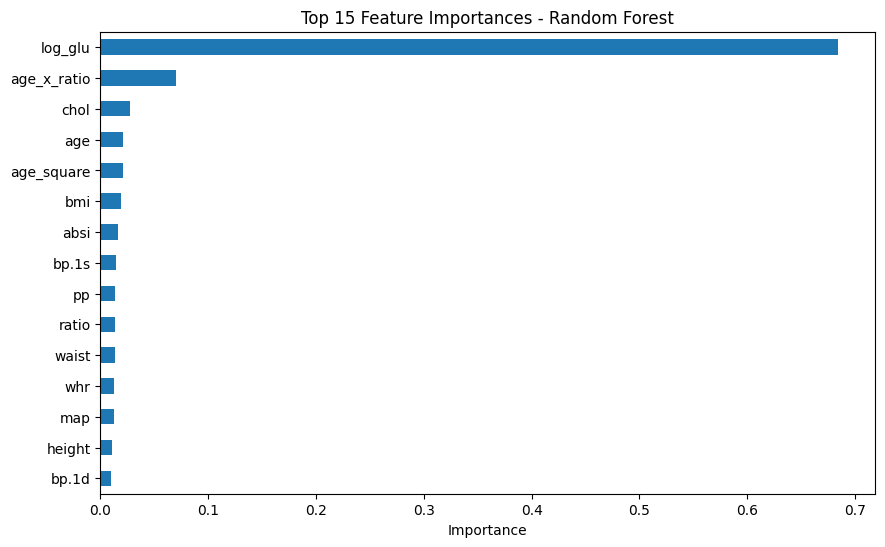

In [49]:
plt.figure(figsize=(10, 6))
feature_importances.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.savefig(folder +"images/feature_importances_RandomForest.png", format='png')
plt.show()

In [50]:
threshold = 0.014
selected_features = feature_importances[feature_importances > threshold].index.tolist()

print(f"Initial Features: {X_train.shape[1]}")
print(f"Features after the cut: {len(selected_features)}")
print("Keeped Features:", selected_features)

Initial Features: 23
Features after the cut: 8
Keeped Features: ['log_glu', 'age_x_ratio', 'chol', 'age', 'age_square', 'bmi', 'absi', 'bp.1s']


In [51]:
X_train_fi = X_train[selected_features]
X_test_fi = X_test[selected_features]

In [52]:
rf_fi = RandomForestRegressor(random_state=42, **random_search.best_params_)
rf_fi.fit(X_train_fi, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)

In [53]:
y_pred_fi = rf_fi.predict(X_test_fi)

print(f"\nFinal results after  Feature Selection:")
print(f"MSE: {mean_squared_error(y_test, y_pred_fi):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_fi):.4f}")


Final results after  Feature Selection:
MSE: 0.0426
R2 Score: 0.5366
